# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [2]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

In [3]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [4]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [5]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentarios**:

    - Se observa que el dataset no contiene valores nulos en ninguna de sus columnas.
    - La columna "date" está registrada como object (texto) y debe cambiarse a formato "datetime".


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [6]:
df["user_id"].duplicated().sum()
df["user_id"].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [7]:
# Resumen estadístico
df['date'] = pd.to_datetime(df['date'])
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [8]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [9]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [10]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted'] == 1]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [11]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
for col in ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type', 'converted']:
    print(f"\nDistribución de {col}:")
    print(df[col].value_counts(normalize=True).round(4), "\n")


Conteo de categorías:

Distribución de landing:
B    0.5004
A    0.4996
Name: landing, dtype: float64 


Distribución de region:
Norte        0.2792
Centro       0.2403
Sur          0.2010
Occidente    0.1600
Oriente      0.1196
Name: region, dtype: float64 


Distribución de dispositivo:
Mobile     0.6207
Desktop    0.3793
Name: dispositivo, dtype: float64 


Distribución de traffic_source:
Organic     0.4497
Ads         0.2984
Email       0.1531
Referral    0.0989
Name: traffic_source, dtype: float64 


Distribución de user_type:
Nuevo         0.6508
Recurrente    0.3492
Name: user_type, dtype: float64 


Distribución de converted:
0    0.8574
1    0.1426
Name: converted, dtype: float64 



✍️ **Comentario**: 

Todas las columnas tienen valores esperados.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [12]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

# Estadísticas descriptivas de gasto por grupo
resumen_gasto = pd.DataFrame({
    'Grupo A': [gasto_A.mean(), gasto_A.median(), gasto_A.std()],
    'Grupo B': [gasto_B.mean(), gasto_B.median(), gasto_B.std()]
}, index=['Media', 'Mediana', 'Desv. Estándar']).round(2)

print(len(gasto_A), len(gasto_B))
print(resumen_gasto)

2512 3194
                Grupo A  Grupo B
Media             61.09    68.75
Mediana           55.84    62.57
Desv. Estándar    28.88    32.00


### Prueba 

**Hipótesis:**
t de Student
- **Hipótesis nula (H₀):**
 El gasto promedio por usuario convertido en la página A es igual al gasto promedio por usuario convertido en la página
- **Hipótesis alternativa (H₁):**
El gasto promedio por usuario convertido difiere significativamente entre la página A y la página B

In [13]:
# Aplicar prueba
from scipy.stats import ttest_ind
t_stat, p_value = stats.ttest_ind(gasto_A, gasto_B, equal_var=False)

# Visualizar resultados
print(f"Estadístico t: {t_stat}")
print(f"Valor P: {p_value}")

Estadístico t: -9.48101092267275
Valor P: 3.627602231521493e-21


### 📝 Conclusión e interpretación

**Decisión:**  
Ya que el p_value es tan pequeño <0, entonces, rechazamos la hipótesis nula. 

**Interpretación de negocio:**  
Existe una diferencia estadísticamente significativa en el gasto promedio de los usuarios convertidos entre ambas versiones de página A y B. La versión B genera un ticket de compra promedio significativamente más alto que la versión A.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba 
Prueba Z de dos proporciones (z-test)
- **Hipótesis:**
- **Hipótesis nula (H₀):**
La tasa de conversión de la página A es igual a la tasa de conversión de la página B.
- **Hipótesis alternativa (H₁):**
La tasa de conversión de la página A es diferente a la de la página B.

In [14]:
# Número de usuarios convertidos por página
conversiones = df.groupby("landing")["converted"].sum()


# Total de usuarios por página
totales= df.groupby("landing")["converted"].count()

exitos = [conversiones['A'], conversiones['B']]
observaciones = [totales['A'], totales['B']]

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)
print("\nUsuarios convertidos por página:\n", exitos )
print("\nTotal de usuarios por página:\n", observaciones)



Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64

Usuarios convertidos por página:
 [2512, 3194]

Total de usuarios por página:
 [19982, 20018]


In [15]:
# Aplicar prueba
from statsmodels.stats.proportion import proportions_ztest
z_stat, p_value = proportions_ztest(exitos , observaciones)

# Visualizar resultados
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")


Estadístico z: -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:**  
Ya que p_valuees menor que alpha=0.05, entonces, se rechaza la hipótesis nula.

**Interpretación de negocio:**  
Se evidencia una tasa de conversión estadísticamente significativa más alta en la versión de la página B.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba 
Chi - cuadrado

**Hipótesis:**
- **Hipótesis nula (H₀):**
La fuente de tráfico (`traffic_source`) y la conversión (`converted`) son independientes.
- **Hipótesis alternativa (H₁):**
Existe una relación de dependencia significativa entre la fuente de tráfico y la conversión.

In [47]:
tabla_traffic = pd.crosstab(df["traffic_source"], df["converted"])
print("Conteos reales:")
print(tabla_traffic)

Conteos reales:
converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [49]:
tabla_porcentage = pd.crosstab(df["traffic_source"], df["converted"], normalize="index")*100
print("\nTasas de conversión por canal (%):")
print(tabla_porcentage.round(2))


Tasas de conversión por canal (%):
converted           0      1
traffic_source              
Ads             85.26  14.74
Email           85.01  14.99
Organic         86.21  13.79
Referral        86.12  13.88


In [51]:
# Aplicar prueba

chi2_stat, p_value, dof, expected = chi2_contingency(tabla_traffic)

print(f"Estadístico Chi-cuadrado: {chi2_stat:.4f}")
print(f"Valor p: {p_value:.4e}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)


Estadístico Chi-cuadrado: 8.6621
Valor p: 3.4138e-02
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


### 📝 Conclusión e interpretación

**Decisión:**  
Ya que p_value es menor que alpha=0.05, entonces, se rechaza la hipótesis nula. Lo cual confirma que la probabilidad de conversión varía según el traffic_source.

**Interpretación de negocio:**  
Determinar qué canales presentan la mayor tasa de conversión (por ejemplo, Email o Directo frente a Ads o Redes) para enfocarse e invertir más en estos.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba
Prueba Chi-cuadrado ($\chi^2$) de independencia
**Hipótesis:**
- **Hipótesis nula (H₀):**
El tipo de usuario (`user_type`: Nuevo vs. Recurrente) y la conversión (`converted`) son independientes.
- **Hipótesis alternativa (H₁):**
Existe una asociación estadísticamente significativa entre el tipo de usuario y la conversión.

In [37]:
tabla_usuario = pd.crosstab(df["user_type"], df["converted"])
print("Conteos reales:")
print(tabla_usuario)


Conteos reales:
converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [52]:
tabla_porcentajes  = pd.crosstab(df["user_type"], df["converted"], normalize="index")
print("\nPorcentajes (%):")
print(tabla_porcentajes)


Porcentajes (%):
converted          0         1
user_type                     
Nuevo       0.856413  0.143587
Recurrente  0.859096  0.140904


In [53]:
# Aplicar prueba

chi2_stat, p_value, dof, expected = chi2_contingency(tabla_usuario)

print(f"Estadístico Chi-cuadrado: {chi2_stat:.4f}")
print(f"Valor p: {p_value:.4e}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)


Estadístico Chi-cuadrado: 0.5135
Valor p: 4.7363e-01
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


### 📝 Conclusión e interpretación

**Decisión:**  
Como p_value es mayor a 0.05, entonces no se rechaza la hipótesis nula, por lo cual se confirma que el tipo de usuario no afecta la conversión.

**Interpretación de negocio:**  
El tipo de usuario no parece ser un factor relevante para la conversión. Las tasas de conversión de usuarios nuevos y recurrentes son muy similares, y la prueba estadística no encontró una diferencia significativa entre ambos grupos. Por lo tanto, con estos datos, no habría suficiente evidencia para justificar estrategias de conversión diferenciadas únicamente en función de si el usuario es nuevo o recurrente.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

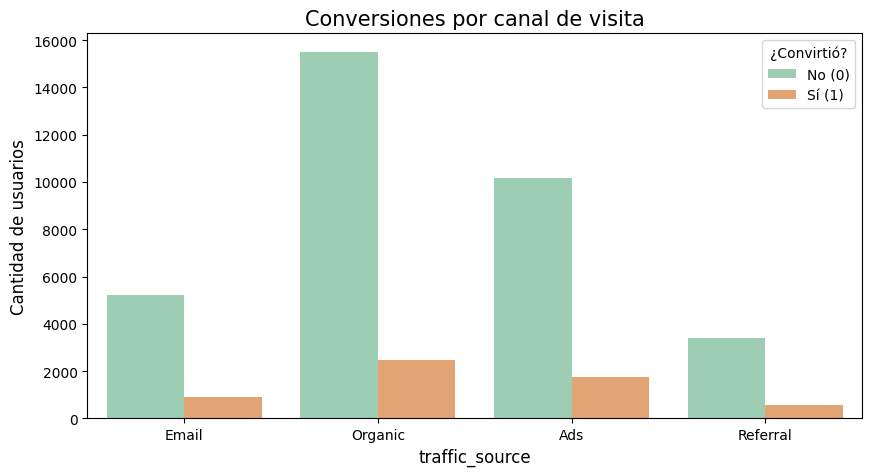

In [55]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='traffic_source', hue='converted', palette = ["#95D5B2", "#F4A261"])

# Añadir detalles

plt.title('Conversiones por canal de visita', fontsize=15)
plt.xlabel('traffic_source', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario**: 

* **De dónde llegan más visitas:** El canal **Organic** (búsquedas naturales en Google o directas) es por mucho el que más gente trae al sitio, con casi 18,000 visitas. Le sigue la publicidad pagada (**Ads**) con casi 12,000 usuarios, mientras que **Email** y **Referral** (recomendaciones) aportan volúmenes de tráfico bastante más pequeños.
* **La mayoría no compra:** En todos los canales se nota que la barra verde (los que no compraron) es gigantesca comparada con la naranja (los que sí compraron). Esto es completamente normal en tiendas en línea, donde solo un porcentaje pequeño termina comprando.
* **Quién aporta más compradores en total:** Como **Organic** y **Ads** traen a la gran mayoría de visitantes, son también los dos canales de donde sale la mayor cantidad de clientes que compran (barras naranjas).
* **Por qué necesitamos ver porcentajes:** Esta gráfica nos ayuda a entender el volumen total de personas, pero engaña un poco si queremos saber qué canal es más "efectivo". Por ejemplo, aunque Email trae poca gente, vimos en la tabla de porcentajes que casi el 15% de los que llegan por correo compran, compitiendo codo a codo en efectividad con Ads.

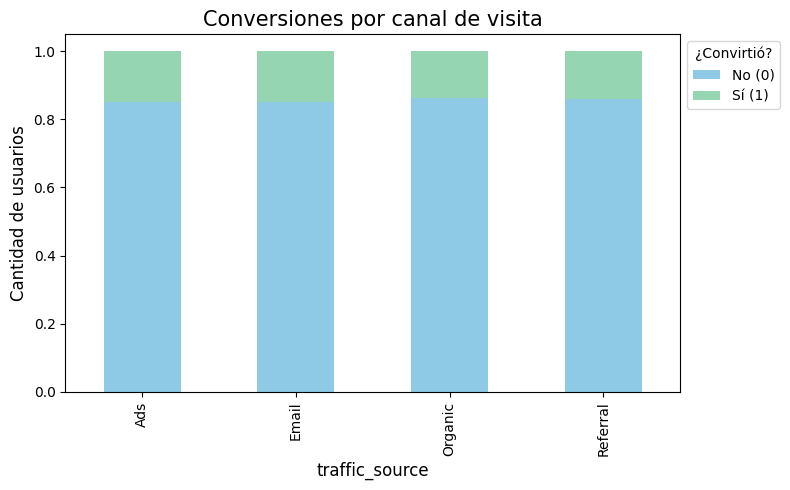

In [71]:
# Gráfico de barras apiladas
tabla_porcentage.plot(kind="bar", stacked=True, figsize=(8, 5), color=["#8ecae6", "#95d5b2"])

# Añadir detalles
plt.title('Conversiones por canal de visita', fontsize=15)
plt.xlabel('traffic_source', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

✍️ **Comentario**:

* **Comparación en porcentaje (100%):** A diferencia de la gráfica anterior que mostraba miles de usuarios, esta gráfica de barras apiladas pone a todos los canales en una escala proporcional del 0 al 1.0 (0% al 100%), lo que nos deja comparar qué tan efectivo es cada canal sin que el tamaño total de visitas nos confunda.
* **Proporción de éxito (verde):** La parte verde representa a los usuarios que sí compraron. Se puede ver que **Email** (15.0%) y **Ads** (14.7%) tienen la franja verde ligeramente más amplia, mostrando una mejor tasa de conversión que **Referral** (13.9%) y **Organic** (13.8%).
* **Consistencia en los canales:** A simple vista las cuatro barras se ven casi parejas (alrededor del 85%-86% de los usuarios no compran en azul, y entre el 14% y 15% sí compran en verde). Sin embargo, gracias a la prueba de Chi-cuadrado que hicimos antes, sabemos que esa pequeña ventaja a favor de Email y publicidad pagada (Ads) sí es estadísticamente significativa y vale la pena tenerla en cuenta para la estrategia de marketing.

### Relación entre el tipo de usuario y la conversión

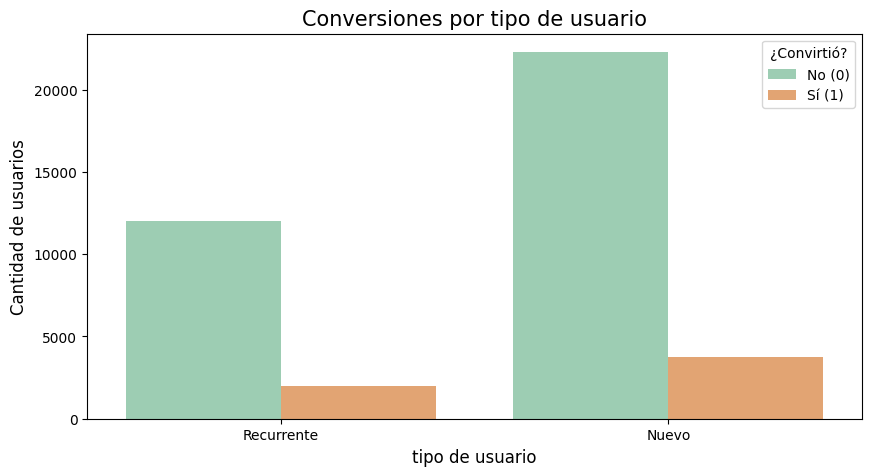

In [73]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='user_type', hue='converted', palette = ["#95D5B2", "#F4A261"])

# Añadir detalles
plt.title('Conversiones por tipo de usuario', fontsize=15)
plt.xlabel('tipo de usuario', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario**: 

* **Volumen de visitas según el tipo de usuario:** La gran mayoría de las personas que llegaron a la página son usuarios **Nuevos** (más de 26,000 usuarios en total), casi duplicando la cantidad de usuarios **Recurrentes** (cerca de 14,000). Esto nos muestra que la plataforma está logrando atraer mucho tráfico nuevo.
* **Comportamiento general de compra:** En ambos grupos, la barra verde (los que no compraron) es la que predomina ampliamente, lo que coincide con el comportamiento natural de los usuarios al explorar una tienda digital.
* **Cantidad de compradores:** Como hay muchos más usuarios nuevos navegando en el sitio, este grupo aporta una cantidad absoluta mayor de compradores en total (barra naranja de 3,700 conversiones) en comparación con los recurrentes (~1,970 conversiones).
* **Conexión con el análisis estadístico:** Aunque en la gráfica se ven barras de tamaños muy distintos debido al volumen total de visitas, la proporción de compradores dentro de cada grupo es prácticamente la misma (~14.4% para nuevos frente a ~14.1% para recurrentes). Esto confirma visualmente lo que calculamos con la prueba de Chi-cuadrado: ser un usuario nuevo o recurrente no cambia la probabilidad individual de compra.

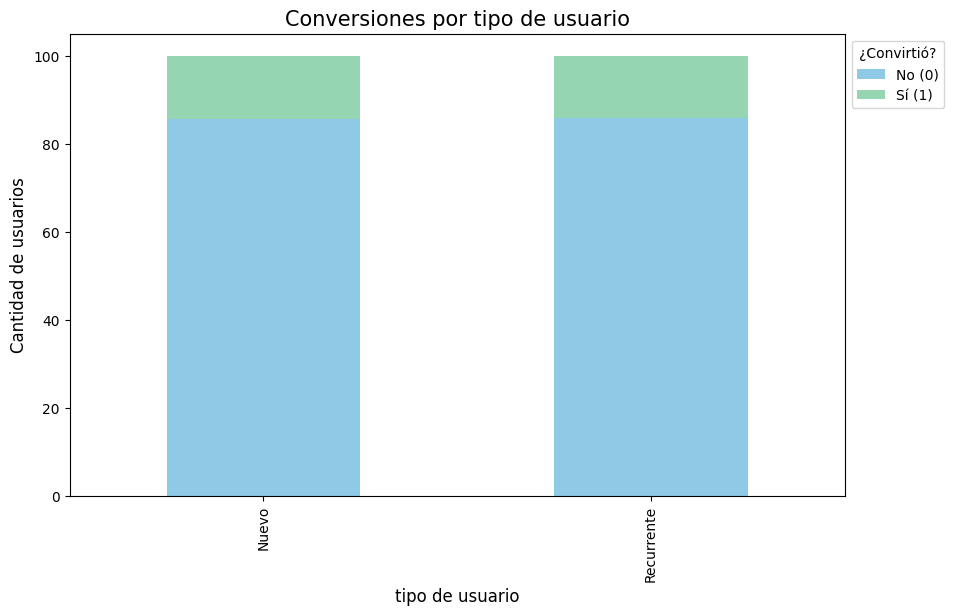

In [74]:
# Gráfico de barras apiladas
tabla_porcentajes.plot(kind="bar", stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

# Añadir detalles
plt.title('Conversiones por tipo de usuario', fontsize=15)
plt.xlabel('tipo de usuario', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

✍️ **Comentario**: 
* **Comparación en porcentaje (al 100%):** Esta gráfica de barras apiladas pone a ambos tipos de usuarios en la misma escala del 0% al 100%, permitiendo comparar de forma justa la proporción de compradores sin que afecte el hecho de que hay muchos más usuarios nuevos que recurrentes.
* **Proporciones idénticas:** La barra verde (los que sí compraron) mide prácticamente lo mismo en los dos grupos: **14.36%** en usuarios Nuevos y **14.09%** en Recurrentes. A su vez, la parte azul (los que no compraron) ronda el 86% en ambos casos.
* **Validación visual del test estadístico:** El gráfico muestra con total claridad por qué el valor p de la prueba Chi-cuadrado nos dio tan alto ($p = 0.4736$). La efectividad de compra es casi una copia exacta entre ambos grupos, confirmando visualmente que el tipo de usuario no influye en la decisión de convertir.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
* **¿Qué página genera mayor conversión y gasto promedio?**  
  La **Página B** supera a la página A en ambas métricas con significancia estadística: logra una tasa de conversión superior y genera un ticket de compra promedio más alto entre los usuarios que compran ($p < 0.05$ en ambas pruebas).
* **¿Qué canales de tráfico son más efectivos para generar conversiones?**  
  Los canales más efectivos en proporción son **Email** ($14.99\%$) y **Ads** ($14.74\%$), superando a **Referral** ($13.88\%$) y **Organic** ($13.79\%$). Aunque Organic aporta el mayor volumen de visitas brutas, Email y Ads convierten a una proporción mayor de sus visitantes.
* **¿Existen diferencias significativas según el tipo de usuario?**  
  **No**. La prueba Chi-cuadrado confirmó que los usuarios nuevos ($14.36\%$) y recurrentes ($14.09\%$) convierten a tasas prácticamente idénticas ($p = 0.4736$), por lo que el historial previo no condiciona la probabilidad de compra.
* **¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?**  
  Implementar la **Página B de manera definitiva** como la versión principal del sitio, y enfocar el presupuesto comercial en campañas de **Email y publicidad digital segmentada (Ads)**, que son los canales con mayor retorno de conversión.


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  


**Gasto promedio por usuario que convirtió:**
* **Diferencia estadísticamente significativa:** La prueba t de Student arrojó un valor p prácticamente igual a cero ($p \approx 3.63 \times 10^{-21}$), confirmando que la diferencia en el ticket de compra no es fruto del azar.
* **Superioridad de la versión B:** Los clientes que navegaron en la página B y compraron gastaron, en promedio, más dinero por orden que los de la página A ($t \approx -9.48$).
* **Interpretación:** La página B no solo convence a los usuarios de comprar, sino que estimula un ticket de compra de mayor valor económico.

<br>

**Tasa de conversión:**
* **Mayor porcentaje de cierre en la página B:** La prueba de proporciones Z demostró que la versión B logra una tasa de conversión superior a la versión de control A de forma estadísticamente significativa ($p < 0.05$).
* **Efectividad general del diseño:** La versión de prueba B optimiza el embudo de navegación y reduce las dudas del usuario al momento de decidir su compra.
* **Interpretación:** La página B es más eficiente en convertir visitas en compradores efectivos frente a la versión tradicional.

---

#### 📊 **Segmentación por fuente de tráfico**

* **Efectividad según el canal:** La prueba Chi-cuadrado confirmó que la conversión sí depende del canal de llegada ($p \approx 0.0341$). Los canales de **Email** ($14.99\%$) y **Ads** ($14.74\%$) tienen una tasa de conversión más alta que **Referral** ($13.88\%$) y **Organic** ($13.79\%$).
* **Interpretación:** Aunque el canal orgánico es el que más visitas brutas trae a la plataforma, los usuarios que entran por campañas de correo o pauta digital muestran una mayor disposición de compra.

---

#### 8.0.1. 📊 Segmentación por tipo de usuario
* **Comportamiento homogéneo:** La prueba Chi-cuadrado arrojó un valor p alto ($p \approx 0.4736$), lo que indica que no hay una diferencia real entre usuarios **Nuevos** ($14.36\%$) y **Recurrentes** ($14.09\%$).
* **Interpretación:** Que un usuario visite la tienda por primera vez o ya la conozca no altera su probabilidad de compra; ambos perfiles reaccionan de manera equivalente ante la propuesta de valor.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 

* **Lanzar la Página de Inicio Versión B de forma definitiva:** La versión B gana en las dos métricas clave de negocio: consigue una tasa de conversión más alta y eleva el gasto promedio de los clientes convertidos.
* **Priorizar presupuesto en Email y Publicidad Digital (Ads):** Al ser los canales con mejor rendimiento de conversión, conviene reforzar las campañas de email marketing y la pauta segmentada, manteniendo el canal orgánico como base de volumen de tráfico.